# Brain Tumor Detection using Deep Learning

### Complete AI Pipeline for Medical Image Analysis




This notebook implements a complete pipeline for detecting brain tumors in MRI images using:

1.  **Data Cleaning and Preprocessing:** This initial phase involves gathering the MRI brain scan dataset and performing essential preprocessing steps such as data cleaning, normalization, and preparing the images for optimal model training.
2.  **Exploratory Data Analysis:** We will conduct a thorough exploratory analysis of the dataset, visualizing image samples and analyzing the distribution of tumourous and non-tumourous cases.
3.  **Image Processing with OpenCV:** Utilizing the OpenCV library, we will apply various image processing techniques including grayscaling, filtering, thresholding, and blurring. A key step here will be visually isolating potential brain tumours using contour detection.
4.  **Model Training and Evaluation:** This core stage involves training a CNN model for the classification task. We will rigorously evaluate the model's performance using metrics such as confusion matrices and by plotting training/validation accuracy curves and ROC curves.
5.  **Analysis and Interpretation:** Finally, we will analyze and interpret the model's predictions by visualizing the results on sample images to understand how the model performs on unseen data.

<a id="setup"></a>
## 1. Setup and Imports
This section initializes the required libraries and sets up the environment
for data processing, model training, and evaluation.

In [13]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [14]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import warnings
warnings.filterwarnings('ignore')


In [17]:
#!pip install git+https://github.com/jacobgil/pytorch-grad-cam.git


In [18]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import random
from tqdm import tqdm
import time

# Image processing
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torch.nn.functional as F


# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split


# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#Grad-Cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image





Using device: cuda


In [19]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Brain-Tumor-Detection-Dataset"
YES_DIR = os.path.join(DATA_DIR, "yes")
NO_DIR  = os.path.join(DATA_DIR, "no")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 30

print("yes images:", len(os.listdir(YES_DIR)))
print("no images:", len(os.listdir(NO_DIR)))


yes images: 1506
no images: 1500


<a id="preprocessing"></a>
## 2. Data Cleaning & Preprocessing

The dataset is organized into two main folders: 'yes' and 'no'.
- The 'yes' folder contains images of brain MRI scans where a tumor is present.
- The 'no' folder contains images of brain MRI scans where no tumor is present.
Each of these folders contains 1500 images. The images in the 'yes' folder are classified as 'tumours', and the images in the 'no' folder are classified as 'non-tumours'. This dataset is suitable for training a binary classification model to distinguish between brain MRI scans with and without tumors.

Images are standardized in orientation, resized to a fixed resolution, converted
to grayscale, and normalized.


Description of each step involved in the data cleaning and processing stage.

1.  **`Filter image`**: Performs checks to determine if an image file is a valid image. If cv2 can read the image and it has valid dimensions it is conisidered as valid image.

2.  **`Rotate Image`**: This function is responsible for rotating the input image. Check if the image width is greater than the image height then rotation is applied.

3.  **`Resize Image`**: This function scales the image to a specific target size (`SIZE` (256, 256)). This is a crucial preprocessing step to ensure all input images have the same dimensions.

4.  **`Convert to grayscale`**: This function converts a color image into a grayscale image. It can reduce the complexity of the input data and the number of parameters in the model, potentially improving training speed and reducing overfitting, especially here color information is not critical for the task.

5.  **`Normalize image`**: This function performs image normalization. This involves scaling the pixel values of the image to a standard range (0-1).


### 2.1 Check for Valid Images

In [20]:
def is_image_valid(img_path):
    try:
        img = Image.open(img_path)
        img.verify()  # Verify that it is an image or not
        return True
    except (IOError, SyntaxError) as e:
        return False



In [21]:
#check for corrupted images in YES_DIR
bad_images = []
for img_name in os.listdir(YES_DIR):
    img_path = os.path.join(YES_DIR, img_name)
    if not is_image_valid(img_path):
        bad_images.append(img_name)
print("Invalid images in YES_DIR:", len(bad_images))


Invalid images in YES_DIR: 0


In [22]:
#check for corrupted images in NO_DIR
bad_images = []

for img_name in os.listdir(NO_DIR):
    img_path = os.path.join(NO_DIR, img_name)
    if not is_image_valid(img_path):
        bad_images.append(img_name)
print("Invalid images in NO_DIR:", len(bad_images))

Invalid images in NO_DIR: 0


### 2.2 Standardize Orientation


In [23]:
def standardize_orientation(image):

    h, w = image.shape[:2]
    if w > h:
        # "Rotate 90° CW if width > height, else return original.
        image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    return image


### 2.3 Resize and Normalize Images


In [24]:
def resize_image(image, target_size=IMG_SIZE):
    """Resize image to target size using area interpolation."""
    return cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

def normalize_image(image):
    """Normalize pixel values to [0, 1] range."""
    if image.dtype != np.float32:
        image = image.astype(np.float32)
    return image / 255.0


### 2.4 Convert to Grayscale

In [25]:
def to_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [26]:
img_path = os.path.join(YES_DIR, os.listdir(YES_DIR)[0])

In [27]:
original = cv2.imread(img_path)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)


In [28]:
#preprocess the image step by step on one image in order to visualize the changes
standardized = standardize_orientation(original)
resized = resize_image(standardized)
gray = to_grayscale(resized)
normalized = normalize_image(gray)


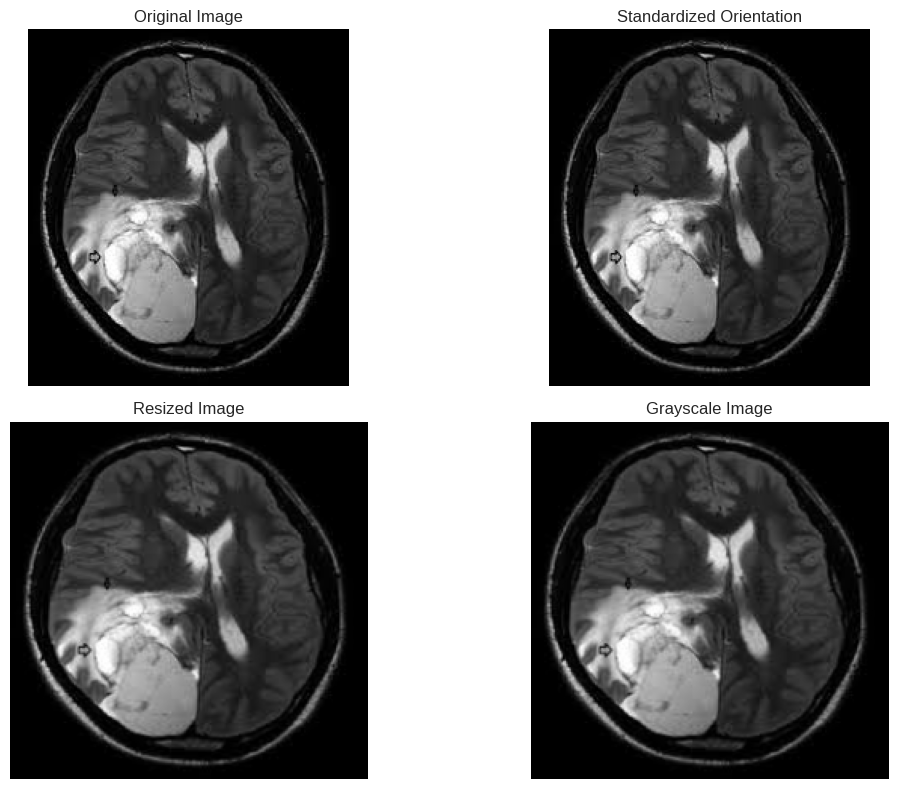

In [29]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(original_rgb)
plt.axis("off")
plt.grid(False)

plt.subplot(2, 2, 2)
plt.title("Standardized Orientation")
plt.imshow(cv2.cvtColor(standardized, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.grid(False)

plt.subplot(2, 2, 3)
plt.title("Resized Image")
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.grid(False)

plt.subplot(2, 2, 4)
plt.title("Grayscale Image")
plt.imshow(gray, cmap="gray",vmin=0, vmax=255)
plt.axis("off")
plt.grid(False)

plt.tight_layout()
plt.show()


In [30]:
print("Original shape:", original.shape)
print("Resized shape :", resized.shape)
print("Grayscale shape:", gray.shape)


Original shape: (237, 213, 3)
Resized shape : (224, 224, 3)
Grayscale shape: (224, 224)


<a id="eda"></a>
## 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the dataset characteristics.
This includes visualizing sample images from each class,class distribution and analyzing variations of image size.

The dataset is balanced with an equal number of tumor and non-tumor images which helps preventing bias during training.


### 3.1 Class Distribution


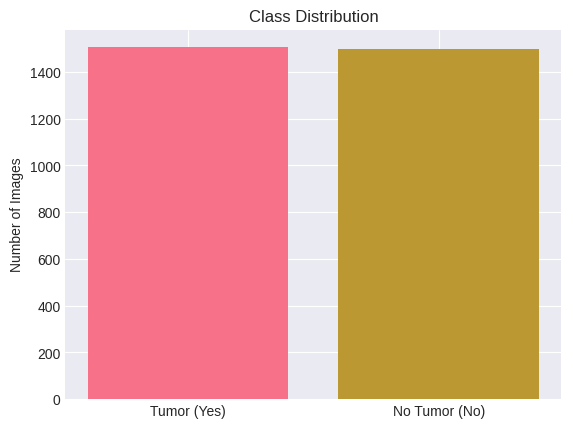

Tumor images: 1506
No tumor images: 1500


In [31]:


yes_count = len(os.listdir(YES_DIR))
no_count  = len(os.listdir(NO_DIR))

plt.bar(["Tumor (Yes)", "No Tumor (No)"], [yes_count, no_count],color=['C0','C1'])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

print("Tumor images:", yes_count)
print("No tumor images:", no_count)


This plot shows the distribution of tumor and non-tumor images.
The dataset is balanced with an equal number of tumor and non-tumor images.
This makes sure fair training and avoids bias toward any class.

### 3.2 Visualize Sample Images


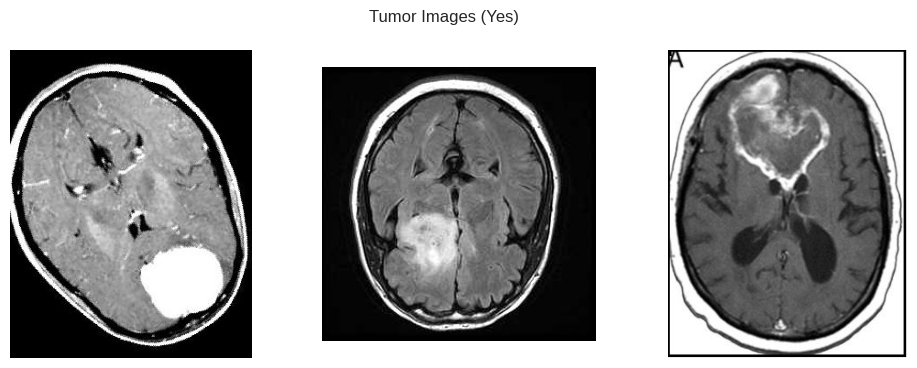

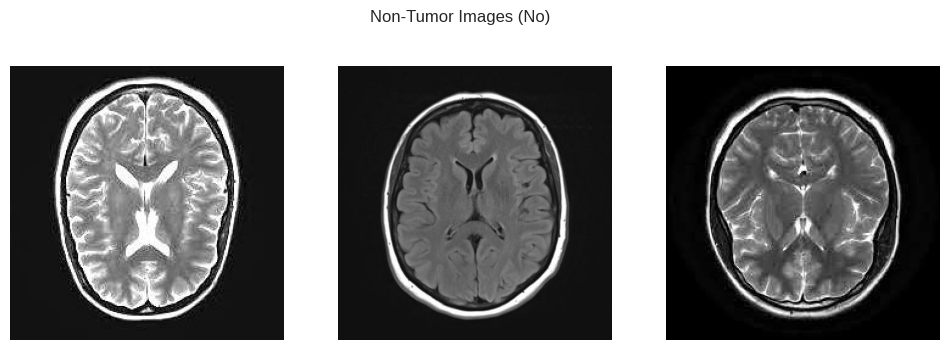

In [32]:

#show random samples from each class
def show_samples(folder, title, n=3):
    files = random.sample(os.listdir(folder), n)
    plt.figure(figsize=(12, 4))

    for i, f in enumerate(files):
        img = Image.open(os.path.join(folder, f))
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

show_samples(YES_DIR, "Tumor Images (Yes)")
show_samples(NO_DIR, "Non-Tumor Images (No)")

Here we shows few sample MRI images from both the classes. The tumor images show abnormal bright regions and the non-tumor images look normal.

In [33]:

sizes = []

for folder in [YES_DIR, NO_DIR]:
    for f in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, f))
        if img is not None:
            sizes.append(img.shape[:2])  # (height, width)

heights = [s[0] for s in sizes]
widths  = [s[1] for s in sizes]

print("Min height:", min(heights), "Max height:", max(heights))
print("Min width :", min(widths),  "Max width :", max(widths))


Min height: 167 Max height: 1427
Min width : 150 Max width : 1920


Before image preprocessing we checked the dimensions of the images. The dataset contained MRI images with different sizes and we need to resize all images for CNN training as CNN requires fixed input size.

### 4. Image Processing with OpenCV
Classical image processing techniques are applied to better understand MRI images.
Grayscale conversion, Gaussian blur, thresholding, and contour detection are used
to highlight abnormal regions.

### 4.1 Filtering Operations (Blur, Threshold)


In [34]:
def detect_tumor_contours(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    return contours, thresh


### 4.2 Tumor Contour Detection (Region Isolation)


In [35]:
def visualize_contour_detection(image_path, label):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load image: {image_path}")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    contours, thresh = detect_tumor_contours(image)

    print("Contours detected:", len(contours))  # DEBUG LINE

    image_with_contours = image_rgb.copy()
    cv2.drawContours(image_with_contours, contours, -1, (255, 0, 0), 2)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(thresh, cmap="gray")
    plt.title("Thresholded")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(image_with_contours)
    plt.title(f"Contours ({len(contours)})")
    plt.axis("off")

    plt.show()


Contours detected: 1


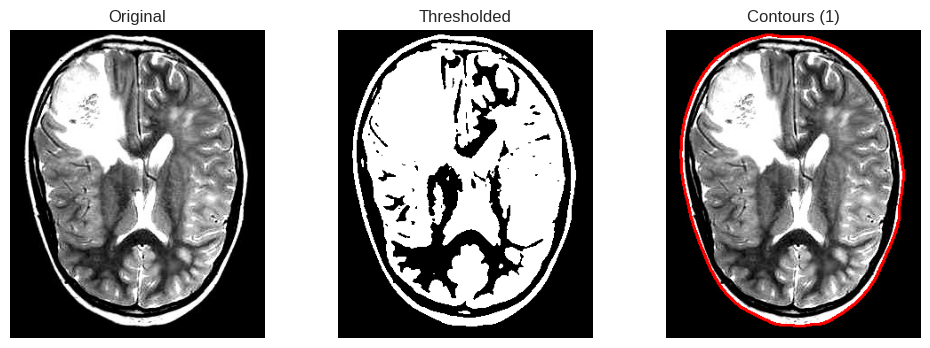

In [36]:
yes_sample = os.path.join(DATA_DIR, "yes", "y0.jpg")
visualize_contour_detection(yes_sample, "Tumor")


Contours detected: 1


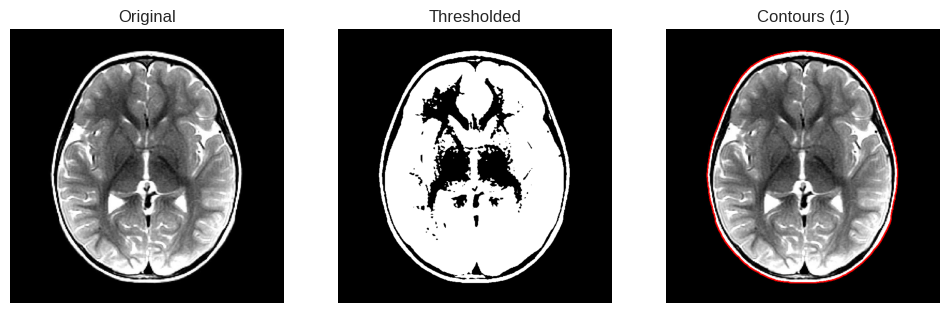

In [37]:
no_sample = os.path.join(DATA_DIR, "no", "no0.jpg")
visualize_contour_detection(no_sample, "No-Tumor")

<a id="training"></a>
## 5. PyTorch Model Training

Convolutional Neural Network (CNN) is used to classify MRI images as tumor or
no tumor. A baseline CNN is first implemented and then later an enhanced CNN
(AdvancedCNN) with additional convolutional layers performed.


### 5.1 Custom Dataset Class


In [38]:
class BrainTumorDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = []
        self.transform = transform

        for label, folder in enumerate(["no", "yes"]):
            folder_path = os.path.join(data_dir, folder)
            for img_name in os.listdir(folder_path):
                self.data.append((os.path.join(folder_path, img_name), label))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, label


### 5.2 Data Augmentation and Transforms


In [39]:
# Data augmentation for training
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Data augmentation (training only)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])



# Simple transform for validation/test (no augmentation)
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("Transforms defined")


Transforms defined


### 5.3 Load and Split Dataset


In [40]:
SEED = 42
torch.manual_seed(SEED)

dataset = BrainTumorDataset(DATA_DIR, transform=None)

n = len(dataset)
train_size = int(0.7 * n)
val_size   = int(0.15 * n)
test_size  = n - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)
# Attach transforms AFTER splitting
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform   = test_transform
test_dataset.dataset.transform  = test_transform

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


Train samples: 2104
Val samples  : 450
Test samples : 452


In [41]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [42]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels:", labels[:5])


Image shape: torch.Size([16, 1, 224, 224])
Labels: tensor([0, 0, 0, 0, 1])


### 5.4 Baseline CustomCNN Training


In [43]:
class BrainTumorCNN(nn.Module):
    def __init__(self):
        super(BrainTumorCNN, self).__init__()

        # Input: 1 × 224 × 224 (grayscale)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # After 3 poolings → 224 → 112 → 56 → 28
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model
model = BrainTumorCNN().to(device)
print(model)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")



BrainTumorCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

Model parameters: 6,446,210


### 5.5 AdvancedCNN Architecture (Double-Conv Blocks)

In [44]:
class AdvancedCNNPlus(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.features = nn.Sequential(
            # Block 1 (1–2)
            conv_block(1, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),      # 224 → 112
            nn.Dropout(dropout),

            # Block 2 (3–4)
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),      # 112 → 56
            nn.Dropout(dropout),

            # Block 3 (5–6)
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),      # 56 → 28
            nn.Dropout(dropout),

            # Block 4 (7–8)
            conv_block(128, 256),
            conv_block(256, 256),
            nn.MaxPool2d(2),      # 28 → 14
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


## 5.6 RESNET-18 Training (Transfer Learning)

In [45]:
from torchvision import models

resnet18 = models.resnet18(pretrained=True)

# Modify first conv layer (1-channel MRI instead of RGB)
resnet18.conv1 = nn.Conv2d(
    1, 64, kernel_size=7, stride=2, padding=3, bias=False
)

# Modify classifier for 2 classes
resnet18.fc = nn.Linear(resnet18.fc.in_features, 2)

resnet18 = resnet18.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


### 5.7 Training Setup & Training Loop (with Validation)

The CNN is trained using the training dataset with data augmentation and
normalization. Cross-entropy loss and the Adam optimizer have been used.
Training loss and accuracy have been monitored across epochs.


In [46]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}


In [47]:
def evaluate(model, dataloader, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return loss_sum / len(dataloader), correct / total


In [48]:
def train_model_with_validation(
    model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=10, patience=5
):
    import copy
    best_model = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    counter = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_loss, val_acc = evaluate(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
            f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_model)
    return model, history


In [49]:
model, history = train_model_with_validation(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=3,
    patience=2
)


Epoch 1: Train Loss=0.4935, Train Acc=0.7643, Val Loss=0.3319, Val Acc=0.8444
Epoch 2: Train Loss=0.2330, Train Acc=0.9035, Val Loss=0.1841, Val Acc=0.9333
Epoch 3: Train Loss=0.1465, Train Acc=0.9501, Val Loss=0.1357, Val Acc=0.9622


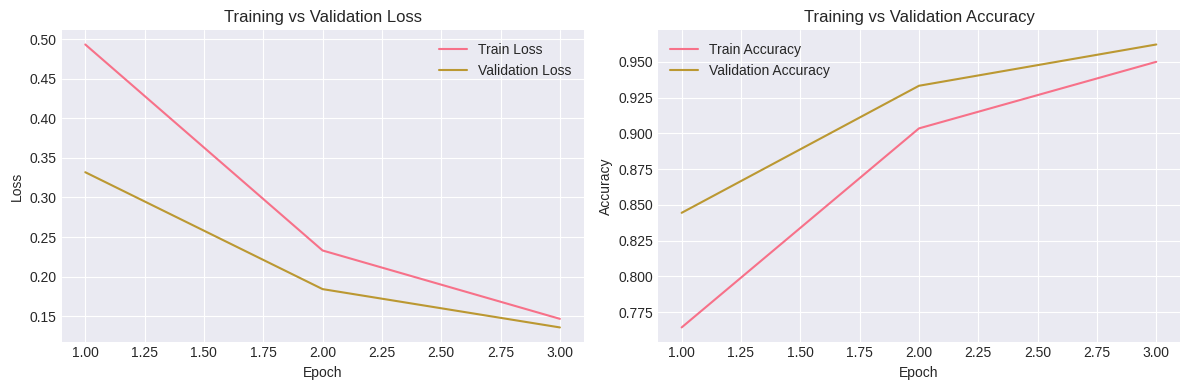

In [50]:

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


From the plot we can see that the CustomCNN learns very fast. Both training and validation loss decrease, and the accuracy improves for both datasets. The curves are close to each other which show good generalization

This plot shows the training loss over epochs. The loss decreases consistently which means effective learning and convergence of the CNN during training.

In [51]:
advanced_model = AdvancedCNNPlus().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(advanced_model.parameters(), lr=1e-4)


In [52]:
advanced_model, adv_history = train_model_with_validation(
    advanced_model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=30,
    patience=6
)


Epoch 1: Train Loss=0.5756, Train Acc=0.7229, Val Loss=0.9225, Val Acc=0.5822
Epoch 2: Train Loss=0.5139, Train Acc=0.7662, Val Loss=0.7255, Val Acc=0.6467
Epoch 3: Train Loss=0.4782, Train Acc=0.7847, Val Loss=0.9126, Val Acc=0.5933
Epoch 4: Train Loss=0.4484, Train Acc=0.8032, Val Loss=0.7432, Val Acc=0.6844
Epoch 5: Train Loss=0.4152, Train Acc=0.8313, Val Loss=0.5785, Val Acc=0.7489
Epoch 6: Train Loss=0.4127, Train Acc=0.8260, Val Loss=0.7804, Val Acc=0.6356
Epoch 7: Train Loss=0.4020, Train Acc=0.8360, Val Loss=0.5069, Val Acc=0.7756
Epoch 8: Train Loss=0.3841, Train Acc=0.8413, Val Loss=0.5844, Val Acc=0.7489
Epoch 9: Train Loss=0.3660, Train Acc=0.8498, Val Loss=0.4424, Val Acc=0.8178
Epoch 10: Train Loss=0.3675, Train Acc=0.8560, Val Loss=0.5115, Val Acc=0.7800
Epoch 11: Train Loss=0.3672, Train Acc=0.8398, Val Loss=0.4154, Val Acc=0.8178
Epoch 12: Train Loss=0.3554, Train Acc=0.8579, Val Loss=0.4635, Val Acc=0.7933
Epoch 13: Train Loss=0.3359, Train Acc=0.8636, Val Loss=0.383

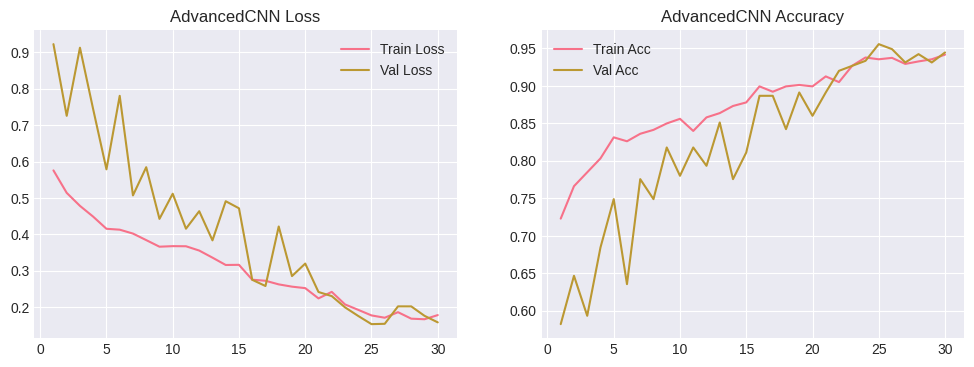

In [53]:
epochs_range = range(1, len(adv_history["train_loss"]) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, adv_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, adv_history["val_loss"], label="Val Loss")
plt.title("AdvancedCNN Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, adv_history["train_acc"], label="Train Acc")
plt.plot(epochs_range, adv_history["val_acc"], label="Val Acc")
plt.title("AdvancedCNN Accuracy")
plt.legend()

plt.show()


This graph shows that the model is learning as the training curve improves over time but the validation curve shows ups and downs. This means the model learns the training data well while its performance on validation data is less stable.

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=1e-4)

resnet18, resnet_history = train_model_with_validation(
    resnet18,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=6,
    patience=3
)


Epoch 1: Train Loss=0.1890, Train Acc=0.9216, Val Loss=0.1114, Val Acc=0.9556
Epoch 2: Train Loss=0.0645, Train Acc=0.9781, Val Loss=0.0695, Val Acc=0.9733
Epoch 3: Train Loss=0.0383, Train Acc=0.9876, Val Loss=0.0217, Val Acc=0.9911
Epoch 4: Train Loss=0.0219, Train Acc=0.9929, Val Loss=0.0508, Val Acc=0.9867
Epoch 5: Train Loss=0.0303, Train Acc=0.9924, Val Loss=0.0447, Val Acc=0.9867
Epoch 6: Train Loss=0.0117, Train Acc=0.9962, Val Loss=0.0498, Val Acc=0.9822
Early stopping


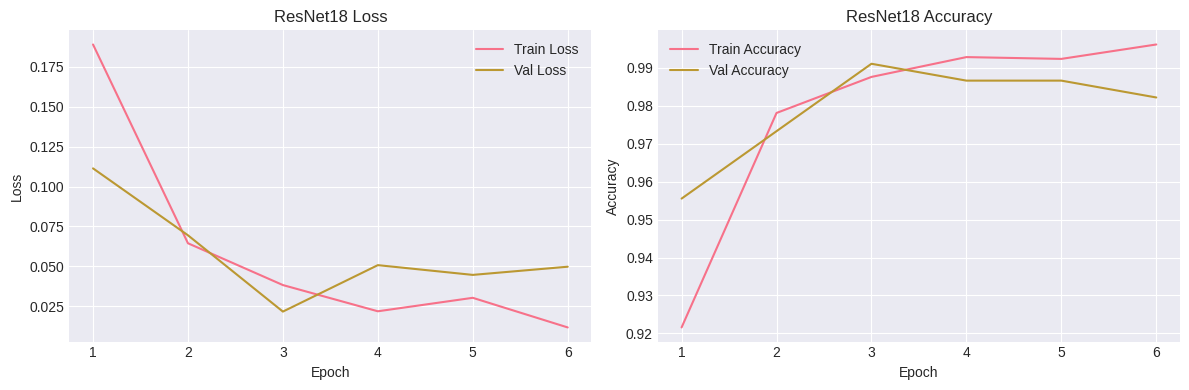

In [55]:

# Epoch range
epochs_range = range(1, len(resnet_history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

# -------- Loss Plot --------
plt.subplot(1, 2, 1)
plt.plot(epochs_range, resnet_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, resnet_history["val_loss"], label="Val Loss")

plt.title("ResNet18 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# -------- Accuracy Plot --------
plt.subplot(1, 2, 2)
plt.plot(epochs_range, resnet_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, resnet_history["val_acc"], label="Val Accuracy")

plt.title("ResNet18 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


From the graph we can see that both training and validation loss drop quickly in the first few epochs. Accuracy for training and validation increases and remains close across epochs. This shows that the model learns efficiently and maintains stable performance on validation data.

<a id="evaluation"></a>


## 6. Model Evaluation
Model performance is evaluated on unseen test data using accuracy,
confusion matrix, and classification metrics. This helps to know how well
the model generalizes to new MRI images.
### 6.1 Load Best Model and Evaluate on Test Set


In [56]:
def evaluate_on_test(model, test_loader, device, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"{model_name} Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

    cm = confusion_matrix(all_labels, all_preds)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Tumor","Tumor"],
                yticklabels=["No Tumor","Tumor"])
    plt.title(f"Confusion Matrix – {model_name}")
    plt.show()

    print(classification_report(
        all_labels, all_preds,
        target_names=["No Tumor","Tumor"]
    ))


###6.2 Confusion Matrix Analysis

CustomCNN Test Accuracy: 0.9513


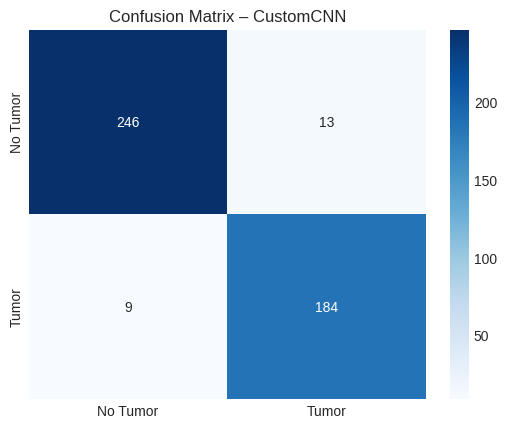

              precision    recall  f1-score   support

    No Tumor       0.96      0.95      0.96       259
       Tumor       0.93      0.95      0.94       193

    accuracy                           0.95       452
   macro avg       0.95      0.95      0.95       452
weighted avg       0.95      0.95      0.95       452



In [57]:
evaluate_on_test(model, test_loader, device, "CustomCNN")


CustomCNN correctly identified 184 out of 193 tumor images, missing 9 tumors, and correctly classified 246 out of 259 no-tumor images with 13 false positives

AdvancedCNN Test Accuracy: 0.9580


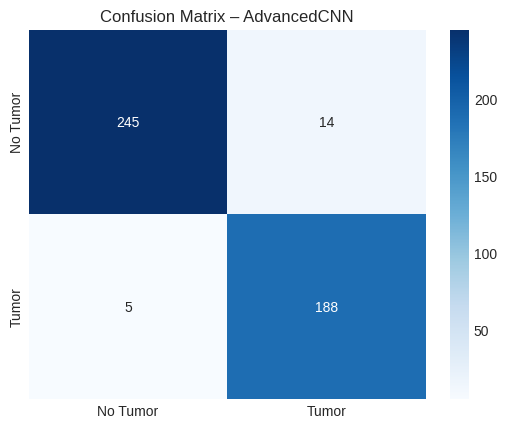

              precision    recall  f1-score   support

    No Tumor       0.98      0.95      0.96       259
       Tumor       0.93      0.97      0.95       193

    accuracy                           0.96       452
   macro avg       0.96      0.96      0.96       452
weighted avg       0.96      0.96      0.96       452



In [58]:
evaluate_on_test(advanced_model, test_loader, device, "AdvancedCNN")

AdvancedCNN correctly identified 188 out of 193 tumor images, missing 5 tumors and correctly classified 245 out of 259 no-tumor images with 14 false positives

ResNet-18 Test Accuracy: 0.9867


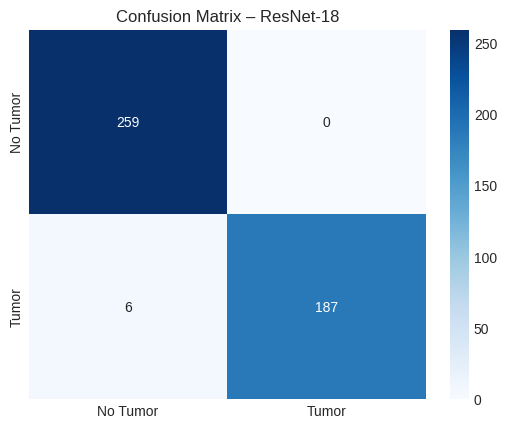

              precision    recall  f1-score   support

    No Tumor       0.98      1.00      0.99       259
       Tumor       1.00      0.97      0.98       193

    accuracy                           0.99       452
   macro avg       0.99      0.98      0.99       452
weighted avg       0.99      0.99      0.99       452



In [59]:
evaluate_on_test(resnet18, test_loader, device, "ResNet-18")


Out of 193 tumor cases, ResNet-18 correctly detected 187 tumors, missing 6 cases, and correctly classified all 259 no-tumor images with no false positives.

<a id="visualization"></a>
## 7. Visualization & Reporting
Predictions are visualized on sample test images. Both correct predictions and misclassified cases are shown to better understand model behavior.
### 7.1 Predictions on Sample Test Images


In [60]:

def visualize_predictions(model, dataset, num_images=6):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    plt.figure(figsize=(12, 6))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        input_img = image.unsqueeze(0).to(device)
        output = model(input_img)
        _, pred = torch.max(output, 1)

        true_label = "Tumor" if label == 1 else "No Tumor"
        pred_label = "Tumor" if pred.item() == 1 else "No Tumor"

        img_np = image.squeeze().cpu().numpy()

        plt.subplot(2, 3, i+1)
        plt.imshow(img_np, cmap="gray")
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


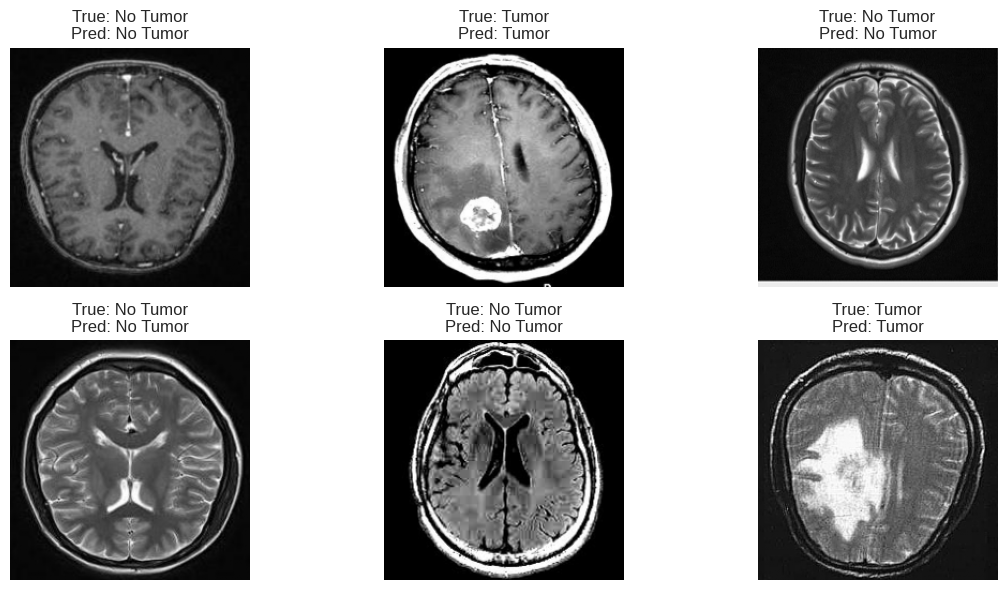

In [61]:
visualize_predictions(resnet18, test_dataset, num_images=6)


These examples show the model’s predictions on unseen test images.
Most predictions match the ground truth, demonstrating good generalization.

### 7.2 Misclassified Images Analysis


In [62]:
def visualize_misclassifications(model, dataset, max_images=4):
    model.eval()
    count = 0

    plt.figure(figsize=(10,4))

    for i in range(len(dataset)):
        image, label = dataset[i]
        input_img = image.unsqueeze(0).to(device)
        output = model(input_img)
        _, pred = torch.max(output, 1)

        if pred.item() != label:
            img_np = image.squeeze().cpu().numpy()
            true_label = "Tumor" if label == 1 else "No Tumor"
            pred_label = "Tumor" if pred.item() == 1 else "No Tumor"

            plt.subplot(1, max_images, count+1)
            plt.imshow(img_np, cmap="gray")
            plt.title(f"True: {true_label}\nPred: {pred_label}")
            plt.axis("off")

            count += 1
            if count == max_images:
                break

    plt.show()


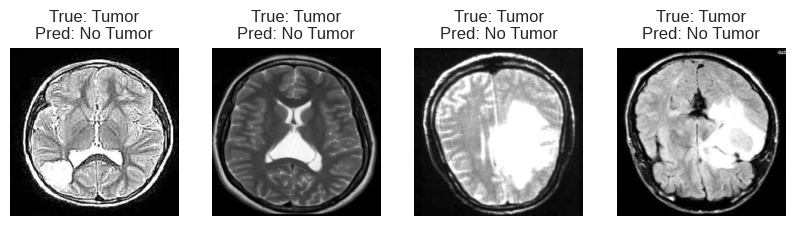

In [63]:
visualize_misclassifications(resnet18, test_dataset)


The figure above shows sample predictions made by the AdvancedCNN on the test dataset.
Each MRI image is displayed along with its true label and the predicted label.

Most samples are correctly classified, indicating that the model has learned meaningful
features to distinguish between tumor and non-tumor MRI scans.

Some misclassified cases are also observed.
In particular, a few tumor images are predicted as "No Tumor" (false negatives).
These cases often correspond to low-contrast or ambiguous MRI slices, where the tumor
region is not clearly distinguishable from surrounding tissue.


### 8. Grad-CAM implementation

To satisfy the tumor localization requirement and improve model interpretability,
Grad-CAM (Gradient-weighted Class Activation Mapping) is applied to the trained CNN.
Grad-CAM highlights regions that contribute most to the model’s prediction.


### 8.1 Grad-CAM for ResNet-18

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet18.to(device)
resnet18.eval()

images, labels = next(iter(test_loader))
input_tensor = images[0].unsqueeze(0).to(device)
label = labels[0].item()


In [65]:
target_layer = resnet18.layer4[-1]


In [66]:
cam = GradCAM(
    model=resnet18,
    target_layers=[target_layer]
)

targets = [ClassifierOutputTarget(label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (H, W)
threshold = 0.5
alpha = 0.5       # transparency

# Prepare grayscale image
img_gray = input_tensor[0].permute(1, 2, 0).cpu().numpy()
img_gray = (img_gray - img_gray.min()) / (img_gray.max() - img_gray.min())

# Convert grayscale to RGB
img_rgb = np.repeat(img_gray, 3, axis=2)

# Create mask from Grad-CAM
cam_mask = grayscale_cam > threshold

# Create blue overlay
overlay = img_rgb.copy()
overlay[cam_mask] = [0.2, 0.4, 1.0]

# Blend
blue_highlight = (1 - alpha) * img_rgb + alpha * overlay


### 8.2 Grad-CAM Visualization Analysis

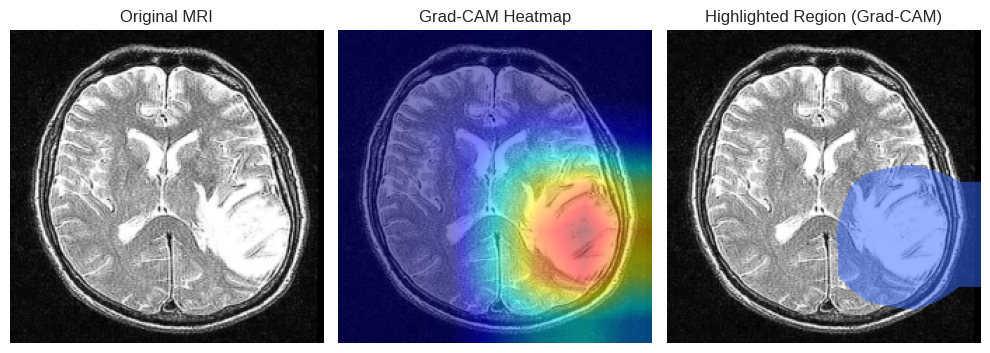

In [67]:
# Standard Grad-CAM
gradcam_vis = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img_gray, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gradcam_vis)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blue_highlight)
plt.title("Highlighted Region (Grad-CAM)")
plt.axis("off")

plt.tight_layout()
plt.show()


The Grad-CAM visualization helps us see where the model is looking when it predicts a tumor. The first image is the original MRI. The second image shows a heatmap, where brighter colors indicate areas that influenced the model more. In the last image, this important area is highlighted in blue to make it clearer. From this, we can see that the model mainly focuses on the tumor region while making its decision.